# E-Commerce

In [ ]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# loading the data
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
customers = pd.read_csv('customers.csv')

In [ ]:
# Joining the datasets
df=pd.merge(orders,customers,on='customer_id',how="inner")
df=pd.merge(df,products,on='product_id',how="inner")
df.head()

,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000


#EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       20 non-null     int64 
 1   customer_id    20 non-null     int64 
 2   product_id     20 non-null     int64 
 3   order_date     20 non-null     object
 4   city           20 non-null     object
 5   quantity       20 non-null     int64 
 6   customer_name  20 non-null     object
 7   signup_date    20 non-null     object
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
# Converting object date columns into datetime format
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       20 non-null     int64         
 1   customer_id    20 non-null     int64         
 2   product_id     20 non-null     int64         
 3   order_date     20 non-null     datetime64[ns]
 4   city           20 non-null     object        
 5   quantity       20 non-null     int64         
 6   customer_name  20 non-null     object        
 7   signup_date    20 non-null     datetime64[ns]
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
# Creating a new column (Revenue)
# formula: revenue=price*quantity
df["Revenue"]=df["quantity"]*df["price"]
df.head()

,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price,Revenue
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000,40000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000,9000


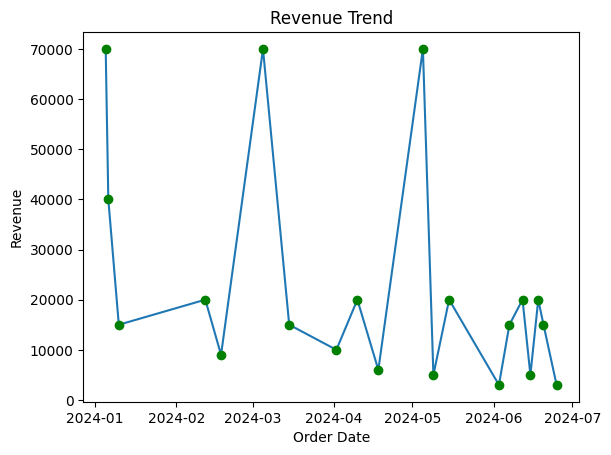

In [ ]:
# Revenue trend by order date
revenue=df.groupby("order_date")["Revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["order_date"],revenue["Revenue"],marker="o",mec="green",mfc="green")
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.title("Revenue Trend by order date")
plt.show()

##The revenue is very less in the last two months (mid of may, june, july)

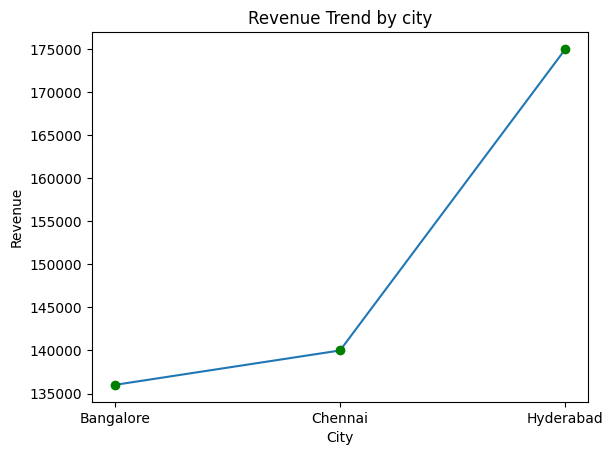

In [ ]:
# Revenue trend by city
revenue=df.groupby("city")["Revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["city"],revenue["Revenue"],marker="o",mec="green",mfc="green")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue Trend by city")
plt.show()

##Revenue is less in Banglore compared to other cities

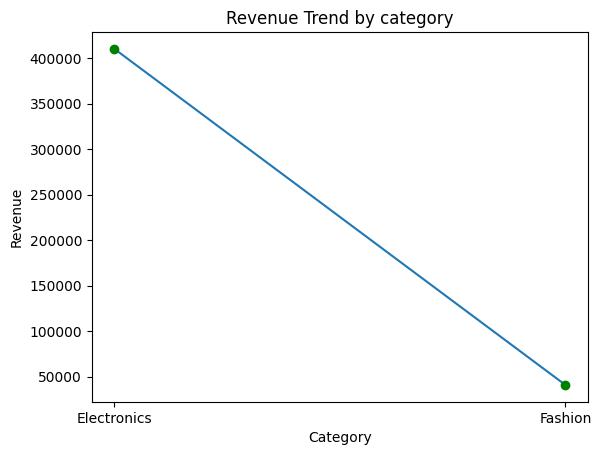

In [ ]:
# Revenue trend by category
revenue=df.groupby("category")["Revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["category"],revenue["Revenue"],marker="o",mec="green",mfc="green")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue Trend by category")
plt.show()

##Revenue is got dropped in fashion category

In [ ]:
# Count customers based on order id (count of orders per customer)
df.groupby("customer_id")["order_id"].count()

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


##Most of the Customers are ordering less

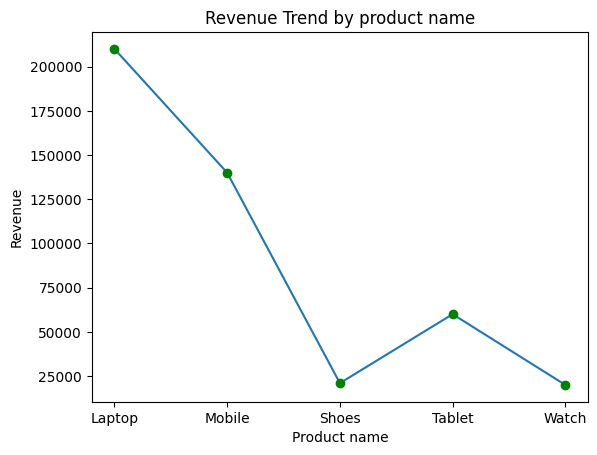

In [ ]:
revenue=df.groupby("product_name")["Revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["product_name"],revenue["Revenue"],marker="o",mec="green",mfc="green")
plt.xlabel("Product name")
plt.ylabel("Revenue")
plt.title("Revenue Trend by product name")
plt.show()

Revenue is very less for shoes and watch (Tablet *Optional)

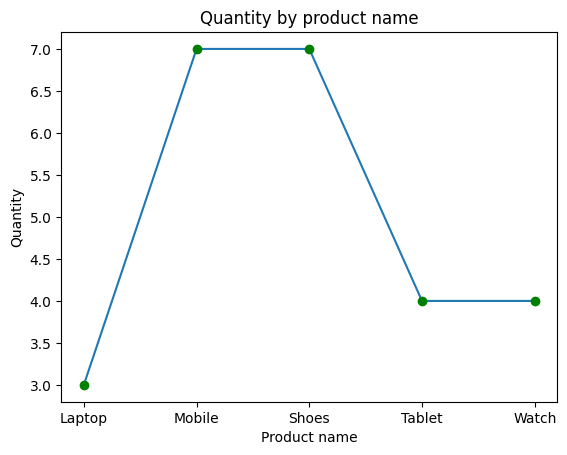

In [ ]:
quantity=df.groupby("product_name")["quantity"].sum()
quantity=pd.DataFrame(quantity).reset_index()
plt.plot(quantity["product_name"],quantity["quantity"],marker="o",mec="green",mfc="green")
plt.xlabel("Product name")
plt.ylabel("Quantity")
plt.title("Quantity by product name")
plt.show()

##Mobile and shoes are most sold products

#Insights:
1. Revenue got dropped in last two months (june,july)
2. Banglore cotributed more in revenue drop
3. Fashion category recorded less revenue
4. Repeated customers ordered less
5. shoe and watch sales declined significantly

#Recommendations:
1. Marketing should be done in banglore
2. Provide discounts for shoe and watch
3. Coupons, discounts, loyalty programs for repeated customers